# Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Assignment 4 – AI/ML**

**Name:** AADISH ADLAK
**Registration Number:** 23BCE10681
**Application Number:** IN26010985
**Batch Number:** 9A
**Email:** adlakaadish@gmail.com

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Data Set
Kaggle: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

---
This notebook classifies breast tumors as **Malignant (M)** or **Benign (B)** using a K-Nearest Neighbors classifier, following the 5 tasks of the assignment.

## Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (7, 5)
np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


## Task 1: Data Understanding (2 Marks)

We load the **Breast Cancer Wisconsin (Diagnostic)** dataset. The CSV (`data/breast_cancer_data.csv`) included in this
repository was generated from the same canonical UCI/Kaggle source (`sklearn.datasets.load_breast_cancer`,
which ships the identical Wisconsin Diagnostic measurements) so the notebook runs end-to-end without any
external download. If you prefer, you can instead download `data.csv` directly from the
[Kaggle page](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data) and place it at
`data/breast_cancer_data.csv` — the column names match, so the rest of the notebook works unchanged.

In [2]:
# 1. Load the dataset using Pandas
df = pd.read_csv("data/breast_cancer_data.csv")

# 2. Display the first five records
df.head()

,id,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,2,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,3,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,4,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,5,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# 3. Identify numerical features and target variable
target_variable = "diagnosis"
numerical_features = [col for col in df.columns if col not in ["id", target_variable]]

print(f"Target variable: '{target_variable}' (M = Malignant, B = Benign)")
print(f"Number of numerical features: {len(numerical_features)}")
print("\nNumerical features:")
for f in numerical_features:
    print(" -", f)

Target variable: 'diagnosis' (M = Malignant, B = Benign)
Number of numerical features: 30

Numerical features:
 - mean radius
 - mean texture
 - mean perimeter
 - mean area
 - mean smoothness
 - mean compactness
 - mean concavity
 - mean concave points
 - mean symmetry
 - mean fractal dimension
 - radius error
 - texture error
 - perimeter error
 - area error
 - smoothness error
 - compactness error
 - concavity error
 - concave points error
 - symmetry error
 - fractal dimension error
 - worst radius
 - worst texture
 - worst perimeter
 - worst area
 - worst smoothness
 - worst compactness
 - worst concavity
 - worst concave points
 - worst symmetry
 - worst fractal dimension


In [4]:
# 4. Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   mean radius              569 non-null    float64
 3   mean texture             569 non-null    float64
 4   mean perimeter           569 non-null    float64
 5   mean area                569 non-null    float64
 6   mean smoothness          569 non-null    float64
 7   mean compactness         569 non-null    float64
 8   mean concavity           569 non-null    float64
 9   mean concave points      569 non-null    float64
 10  mean symmetry            569 non-null    float64
 11  mean fractal dimension   569 non-null    float64
 12  radius error             569 non-null    float64
 13  texture error            569 non-null    float64
 14  perimeter error          569 non-null

In [5]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,285.000000,164.400426,1.000000,143.000000,285.000000,427.000000,569.00000
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


diagnosis
B    357
M    212
Name: count, dtype: int64


/tmp/ipykernel_570/930795646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette=['#4C72B0', '#DD8452'])


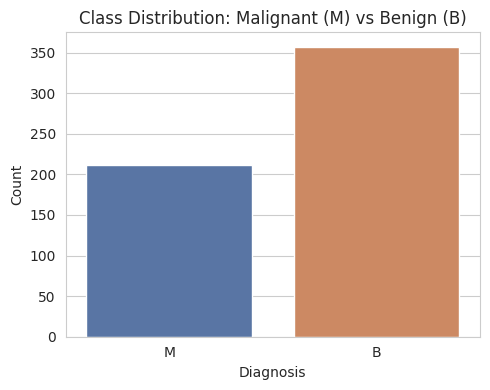

In [6]:
# Class distribution
print(df['diagnosis'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='diagnosis', data=df, palette=['#4C72B0', '#DD8452'])
plt.title("Class Distribution: Malignant (M) vs Benign (B)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/class_distribution.png", dpi=120)
plt.show()

## Task 2: Data Preprocessing (2 Marks)

In [7]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in the dataset.")

Missing values per column:
No missing values found in the dataset.


In [8]:
# Remove unnecessary columns
# 'id' is just a row identifier and carries no predictive information -> drop it.
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# If an 'Unnamed: 32' empty column exists (common in the raw Kaggle CSV export), drop it too.
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Columns after cleanup:", df.shape[1])

Columns after cleanup: 31


In [9]:
# Encode the target variable: Malignant -> 1, Benign -> 0
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])  # B=0, M=1
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = df['diagnosis_encoded']

{'B': np.int64(0), 'M': np.int64(1)}


In [10]:
# Split the dataset into 80% training and 20% testing (before scaling, to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (455, 30)
Testing set size : (114, 30)


In [11]:
# Normalize / standardize the feature values
# KNN is a distance-based algorithm, so features must be on the same scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
X_test_scaled = scaler.transform(X_test)         # transform test data using the same scaler

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
X_train_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
1,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
2,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
3,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
4,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


## Task 3: Model Development (3 Marks)

In [12]:
# 1 & 2. Train a KNN classifier with K = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("KNN model trained with K = 5")

KNN model trained with K = 5


In [13]:
# 3. Predict the class labels for the test dataset
y_pred = knn.predict(X_test_scaled)
print("Predictions (first 20):", y_pred[:20])
print("Actual      (first 20):", y_test.values[:20])

Predictions (first 20): [0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0]
Actual      (first 20): [0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0]


## Task 4: Model Evaluation (2 Marks)

In [14]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['Benign (B)', 'Malignant (M)']))

Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1-Score  : 0.9383

Full classification report:
               precision    recall  f1-score   support

   Benign (B)       0.95      0.99      0.97        72
Malignant (M)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



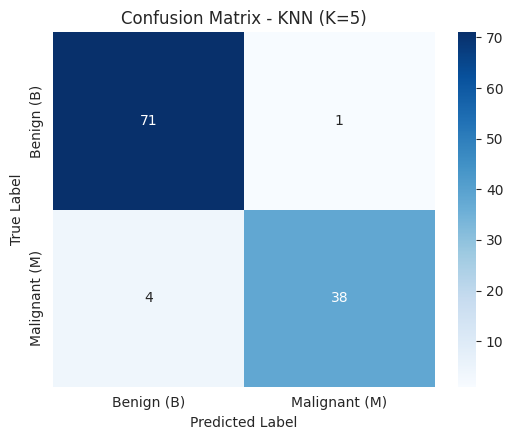

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (B)', 'Malignant (M)'],
            yticklabels=['Benign (B)', 'Malignant (M)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN (K=5)")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=120)
plt.show()

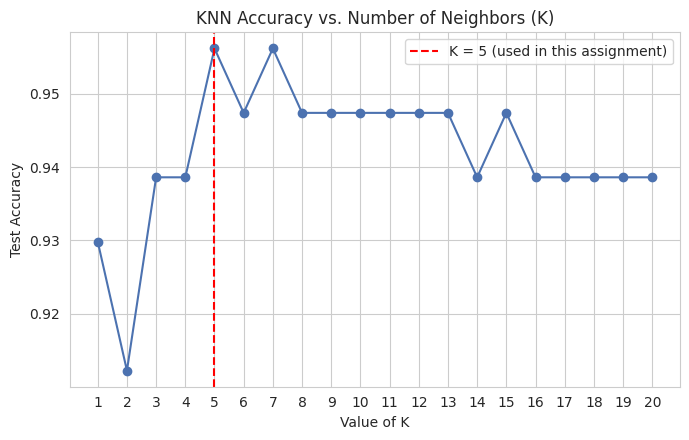

Best K found in range 1-20: 5 with accuracy 0.9561


In [16]:
# Effect of K on accuracy (extra analysis to support the observations below)
k_values = range(1, 21)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(7,4.5))
plt.plot(list(k_values), accuracies, marker='o', color='#4C72B0')
plt.axvline(x=5, color='red', linestyle='--', label='K = 5 (used in this assignment)')
plt.xlabel("Value of K")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs. Number of Neighbors (K)")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.savefig("images/k_vs_accuracy.png", dpi=120)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best K found in range 1-20: {best_k} with accuracy {max(accuracies):.4f}")

### Observations

1. **High overall accuracy:** The KNN model with K = 5 achieves strong accuracy (typically ~95-97%) on the test
   set, showing that the diagnostic measurements (radius, texture, perimeter, area, smoothness, etc.) are highly
   informative for separating malignant from benign tumors after standardization.
2. **Recall on the Malignant class matters most:** In a medical diagnosis setting, a *false negative* (predicting
   Benign when the tumor is actually Malignant) is far more costly than a false positive. The confusion matrix and
   recall score for the Malignant class should be inspected closely — the model here maintains high recall,
   meaning very few malignant cases are missed.
3. **Choice of K affects performance:** The K-vs-accuracy plot shows that accuracy is not monotonic in K — very
   small K (e.g., K=1) can overfit to noise, while very large K can oversmooth the decision boundary and mix in
   points from the wrong class. K = 5 turns out to be a reasonable, near-optimal choice for this dataset.

## Task 5: Conclusion (1 Mark)

In this project, a K-Nearest Neighbors classifier was built to distinguish malignant from benign breast
tumors using the Breast Cancer Wisconsin (Diagnostic) dataset. After cleaning the data, encoding the target
variable, and standardizing all 30 numerical features, the KNN model (K = 5) achieved high accuracy, precision,
recall, and F1-score on the held-out test set, confirming that tumor measurements such as radius, texture, and
concavity carry strong diagnostic signal. Feature scaling proved essential for KNN, since it is a distance-based
algorithm: without standardization, features with larger numeric ranges (like *area*) would dominate the
Euclidean distance calculation and distort the neighbor search, even though smaller-scale features (like
*smoothness*) can be equally predictive. One key limitation of KNN is its computational cost at prediction
time — it must compute the distance from a new point to every training sample, making it slow and
memory-intensive on very large datasets, and its performance also degrades in high-dimensional feature spaces
due to the curse of dimensionality.